<a href="https://colab.research.google.com/github/priya5032007/Irrigation/blob/main/agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("agricultural_data_uncleaned.csv")

df.head()

,Timestamp,Farm_ID,Soil_Moisture,Temperature,Humidity,Rainfall,Crop_Stage,Irrigation_Status,Crop_Outcome
0,2026-05-01 08:00:00,FARM_001,34.2,28.5,65.0,0.0,Vegetative,0,Good
1,2026-05-01 09:00:00,FARM_001,32.1,30.1,62.0,0.0,Vegetative,0,Good
2,2026-05-01 10:00:00,FARM_001,28.5,32.4,58.0,0.0,Vegetative,1,Good
3,2026-05-01 11:00:00,FARM_001,45.0,33.1,55.0,0.0,Vegetative,0,Good
4,2026-05-01 12:00:00,FARM_001,42.8,35.0,50.0,0.0,Vegetative,0,Good


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 109
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          109 non-null    object 
 1   Farm_ID            109 non-null    object 
 2   Soil_Moisture      108 non-null    float64
 3   Temperature        109 non-null    float64
 4   Humidity           109 non-null    float64
 5   Rainfall           109 non-null    float64
 6   Crop_Stage         108 non-null    object 
 7   Irrigation_Status  109 non-null    int64  
 8   Crop_Outcome       109 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 7.8+ KB


In [ ]:
df.isnull().sum()

,0
Timestamp,0
Farm_ID,0
Soil_Moisture,1
Temperature,0
Humidity,0
Rainfall,0
Crop_Stage,1
Irrigation_Status,0
Crop_Outcome,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [ ]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 108


In [ ]:
df["Soil_Moisture"] = df["Soil_Moisture"].fillna(
    df["Soil_Moisture"].median()
)

In [ ]:
df["Crop_Stage"] = df["Crop_Stage"].fillna(
    df["Crop_Stage"].mode()[0]
)

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Timestamp            0
Farm_ID              0
Soil_Moisture        0
Temperature          0
Humidity             0
Rainfall             0
Crop_Stage           0
Irrigation_Status    0
Crop_Outcome         0
dtype: int64


In [ ]:
df.describe()

,Soil_Moisture,Temperature,Humidity,Rainfall,Irrigation_Status
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,34.966667,33.021296,56.222222,1.967593,0.314815
std,25.866436,8.404739,17.730239,5.550227,0.486224
min,-12.000000,23.000000,25.000000,0.000000,0.000000
25%,20.875000,29.000000,41.750000,0.000000,0.000000
50%,32.100000,32.450000,58.000000,0.000000,0.000000
75%,43.625000,36.575000,68.000000,0.000000,1.000000
max,250.000000,105.000000,92.000000,30.000000,2.000000


In [ ]:
print("Crop Stages:")
print(df["Crop_Stage"].unique())

print("\nIrrigation Status:")
print(df["Irrigation_Status"].unique())

print("\nCrop Outcomes:")
print(df["Crop_Outcome"].unique())

Crop Stages:
['Vegetative' 'Flowering' 'flowering' 'Ripening' 'Germination']

Irrigation Status:
[0 1 2]

Crop Outcomes:
['Good' 'Failure']


In [ ]:
print("Negative Soil Moisture:",
      (df["Soil_Moisture"] < 0).sum())

print("Negative Temperature:",
      (df["Temperature"] < 0).sum())

print("Negative Humidity:",
      (df["Humidity"] < 0).sum())

print("Negative Rainfall:",
      (df["Rainfall"] < 0).sum())

Negative Soil Moisture: 1
Negative Temperature: 0
Negative Humidity: 0
Negative Rainfall: 0


In [ ]:
df.head(10)

,Timestamp,Farm_ID,Soil_Moisture,Temperature,Humidity,Rainfall,Crop_Stage,Irrigation_Status,Crop_Outcome
0,2026-05-01 08:00:00,FARM_001,34.2,28.5,65.0,0.0,Vegetative,0,Good
1,2026-05-01 09:00:00,FARM_001,32.1,30.1,62.0,0.0,Vegetative,0,Good
2,2026-05-01 10:00:00,FARM_001,28.5,32.4,58.0,0.0,Vegetative,1,Good
3,2026-05-01 11:00:00,FARM_001,45.0,33.1,55.0,0.0,Vegetative,0,Good
4,2026-05-01 12:00:00,FARM_001,42.8,35.0,50.0,0.0,Vegetative,0,Good
6,2026-05-02 08:00:00,FARM_001,38.0,27.9,68.0,12.5,Vegetative,0,Good
7,2026-05-02 09:00:00,FARM_001,48.2,26.5,82.0,5.0,Vegetative,1,Good
8,2026-05-02 10:00:00,FARM_001,52.0,27.0,80.0,0.0,Vegetative,0,Good
9,2026-05-03 08:00:00,FARM_001,22.1,36.2,42.0,0.0,Flowering,1,Good
10,2026-05-03 09:00:00,FARM_001,32.1,38.0,40.0,0.0,Flowering,1,Good


In [ ]:
df.to_csv("agricultural_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
from google.colab import files

files.download("agricultural_data_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("agricultural_data_cleaned.csv")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Cleaned dataset loaded successfully!")
print(df.shape)
display(df.head())

Cleaned dataset loaded successfully!
(108, 9)


,Timestamp,Farm_ID,Soil_Moisture,Temperature,Humidity,Rainfall,Crop_Stage,Irrigation_Status,Crop_Outcome
0,2026-05-01 08:00:00,FARM_001,34.2,28.5,65.0,0.0,Vegetative,0,Good
1,2026-05-01 09:00:00,FARM_001,32.1,30.1,62.0,0.0,Vegetative,0,Good
2,2026-05-01 10:00:00,FARM_001,28.5,32.4,58.0,0.0,Vegetative,1,Good
3,2026-05-01 11:00:00,FARM_001,45.0,33.1,55.0,0.0,Vegetative,0,Good
4,2026-05-01 12:00:00,FARM_001,42.8,35.0,50.0,0.0,Vegetative,0,Good


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("agricultural_data_cleaned.csv")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Cleaned dataset loaded successfully!")
print(df.shape)
display(df.head())

Cleaned dataset loaded successfully!
(108, 9)


,Timestamp,Farm_ID,Soil_Moisture,Temperature,Humidity,Rainfall,Crop_Stage,Irrigation_Status,Crop_Outcome
0,2026-05-01 08:00:00,FARM_001,34.2,28.5,65.0,0.0,Vegetative,0,Good
1,2026-05-01 09:00:00,FARM_001,32.1,30.1,62.0,0.0,Vegetative,0,Good
2,2026-05-01 10:00:00,FARM_001,28.5,32.4,58.0,0.0,Vegetative,1,Good
3,2026-05-01 11:00:00,FARM_001,45.0,33.1,55.0,0.0,Vegetative,0,Good
4,2026-05-01 12:00:00,FARM_001,42.8,35.0,50.0,0.0,Vegetative,0,Good


In [ ]:
print("Average Soil Moisture:",
      df["Soil_Moisture"].mean())

print("Average Temperature:",
      df["Temperature"].mean())

print("Average Humidity:",
      df["Humidity"].mean())

print("Average Rainfall:",
      df["Rainfall"].mean())

Average Soil Moisture: 35.375
Average Temperature: 33.0212962962963
Average Humidity: 56.22222222222222
Average Rainfall: 1.9675925925925926


In [ ]:
print("========== IRRIGATION STATUS ==========")

print(df["Irrigation_Status"].value_counts())

print("\nPercentage:")
print(
    df["Irrigation_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

========== IRRIGATION STATUS ==========
Irrigation_Status
0    75
1    32
2     1
Name: count, dtype: int64

Percentage:
Irrigation_Status
0    69.44
1    29.63
2     0.93
Name: proportion, dtype: float64


In [ ]:
moisture_threshold = df["Soil_Moisture"].quantile(0.25)

print(
    "Low soil-moisture threshold:",
    moisture_threshold
)

Low soil-moisture threshold: 21.375


In [ ]:
print("========== CROP STAGE ANALYSIS ==========")

crop_stage_analysis = df.groupby(
    "Crop_Stage"
).agg(
    Average_Soil_Moisture=("Soil_Moisture", "mean"),
    Average_Rainfall=("Rainfall", "mean"),
    Average_Temperature=("Temperature", "mean")
)

display(crop_stage_analysis)

========== CROP STAGE ANALYSIS ==========


,Average_Soil_Moisture,Average_Rainfall,Average_Temperature
Crop_Stage,,,
Flowering,25.672222,0.000000,39.294444
Germination,56.060000,9.000000,25.360000
Ripening,32.904167,0.625000,32.079167
Vegetative,36.051852,0.648148,31.014815
flowering,12.000000,0.000000,37.200000


In [ ]:
print("========== IRRIGATION vs CROP OUTCOME ==========")

outcome_analysis = pd.crosstab(
    df["Irrigation_Status"],
    df["Crop_Outcome"]
)

display(outcome_analysis)

========== IRRIGATION vs CROP OUTCOME ==========


Crop_Outcome,Failure,Good
Irrigation_Status,,
0,14,61
1,12,20
2,0,1


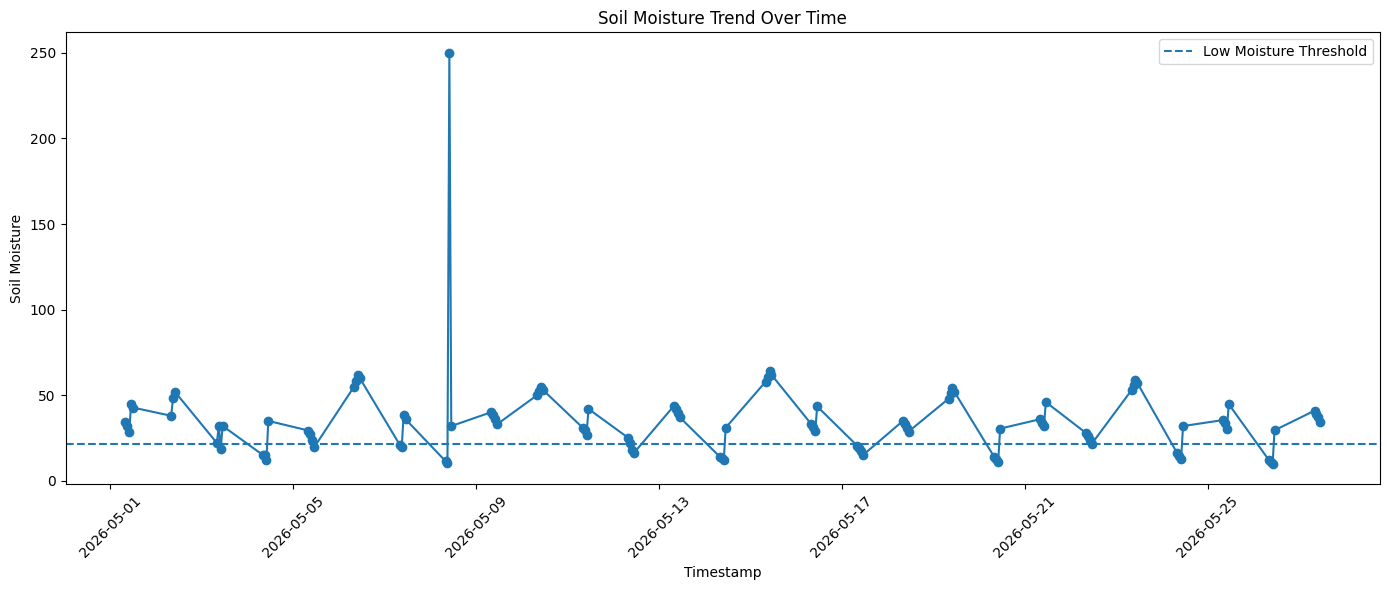

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Timestamp"],
    df["Soil_Moisture"],
    marker="o"
)

plt.axhline(
    moisture_threshold,
    linestyle="--",
    label="Low Moisture Threshold"
)

plt.xlabel("Timestamp")
plt.ylabel("Soil Moisture")
plt.title("Soil Moisture Trend Over Time")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

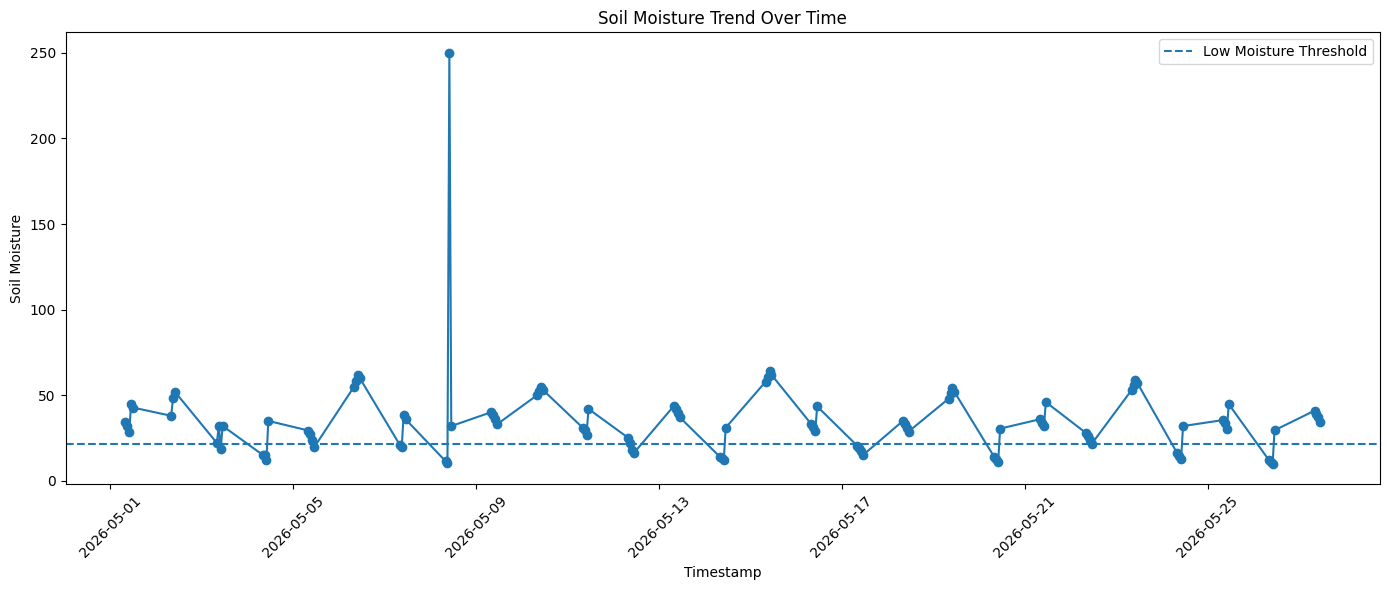

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Timestamp"],
    df["Soil_Moisture"],
    marker="o"
)

plt.axhline(
    moisture_threshold,
    linestyle="--",
    label="Low Moisture Threshold"
)

plt.xlabel("Timestamp")
plt.ylabel("Soil Moisture")
plt.title("Soil Moisture Trend Over Time")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

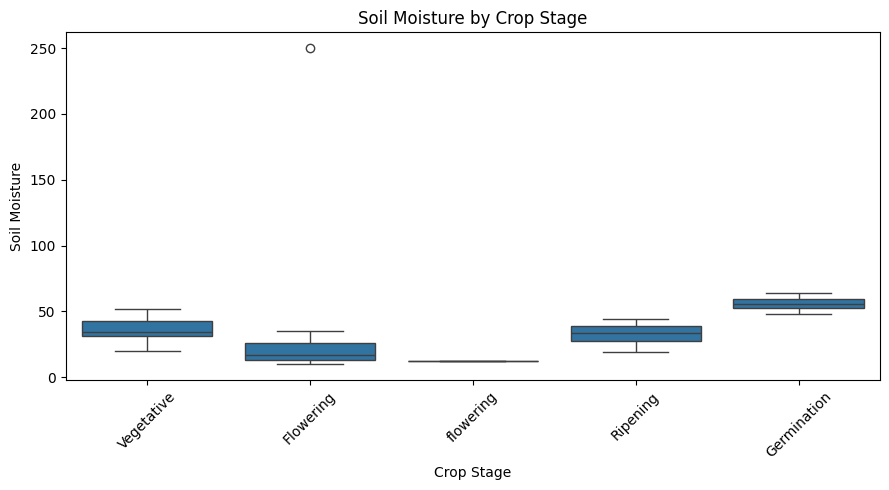

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Crop_Stage",
    y="Soil_Moisture"
)

plt.xlabel("Crop Stage")
plt.ylabel("Soil Moisture")
plt.title("Soil Moisture by Crop Stage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

X = df[
    [
        "Soil_Moisture",
        "Temperature",
        "Humidity",
        "Rainfall",
        "Crop_Stage"
    ]
].copy()

y = df["Irrigation_Status"]

In [ ]:
crop_encoder = LabelEncoder()

X["Crop_Stage"] = crop_encoder.fit_transform(
    X["Crop_Stage"]
)

In [ ]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8181818181818182

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.71      0.71      0.71         7

    accuracy                           0.82        22
   macro avg       0.79      0.79      0.79        22
weighted avg       0.82      0.82      0.82        22


Confusion Matrix:
[[13  2]
 [ 2  5]]


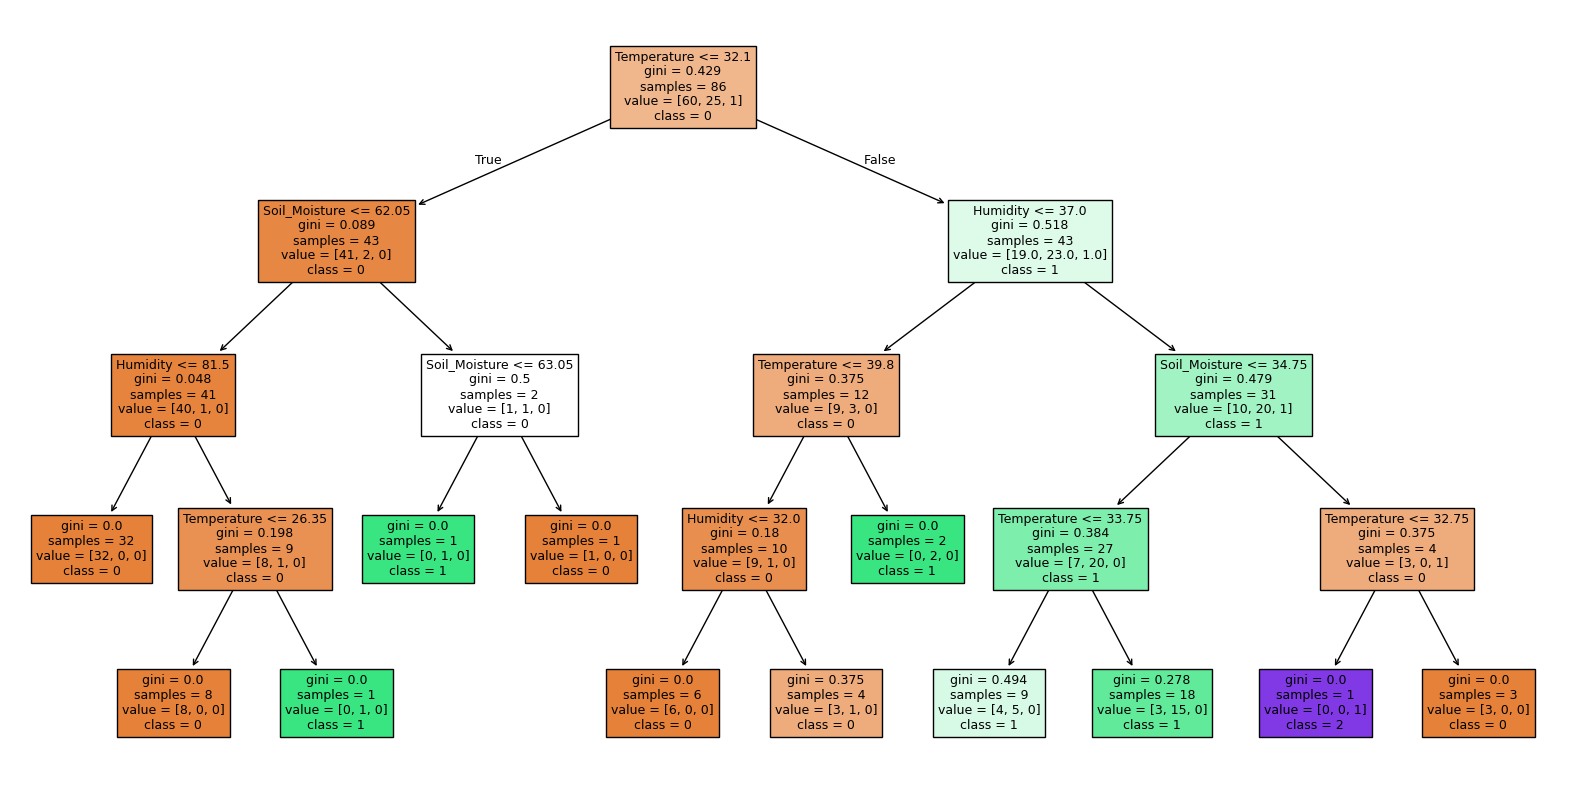

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True
)

plt.show()

Temperature      0.681862
Soil_Moisture    0.186413
Humidity         0.131726
Rainfall         0.000000
Crop_Stage       0.000000
dtype: float64


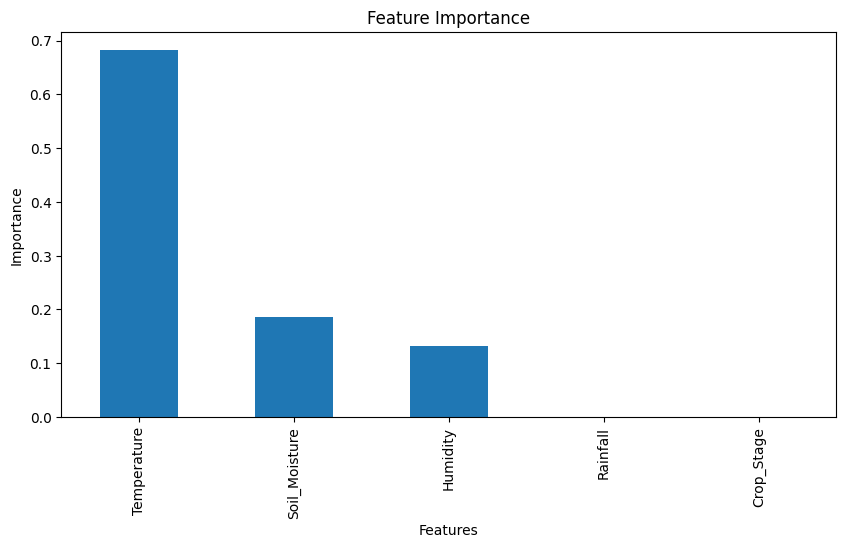

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")

Accuracy: 0.8181818181818182

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.71      0.71      0.71         7

    accuracy                           0.82        22
   macro avg       0.79      0.79      0.79        22
weighted avg       0.82      0.82      0.82        22


Confusion Matrix:


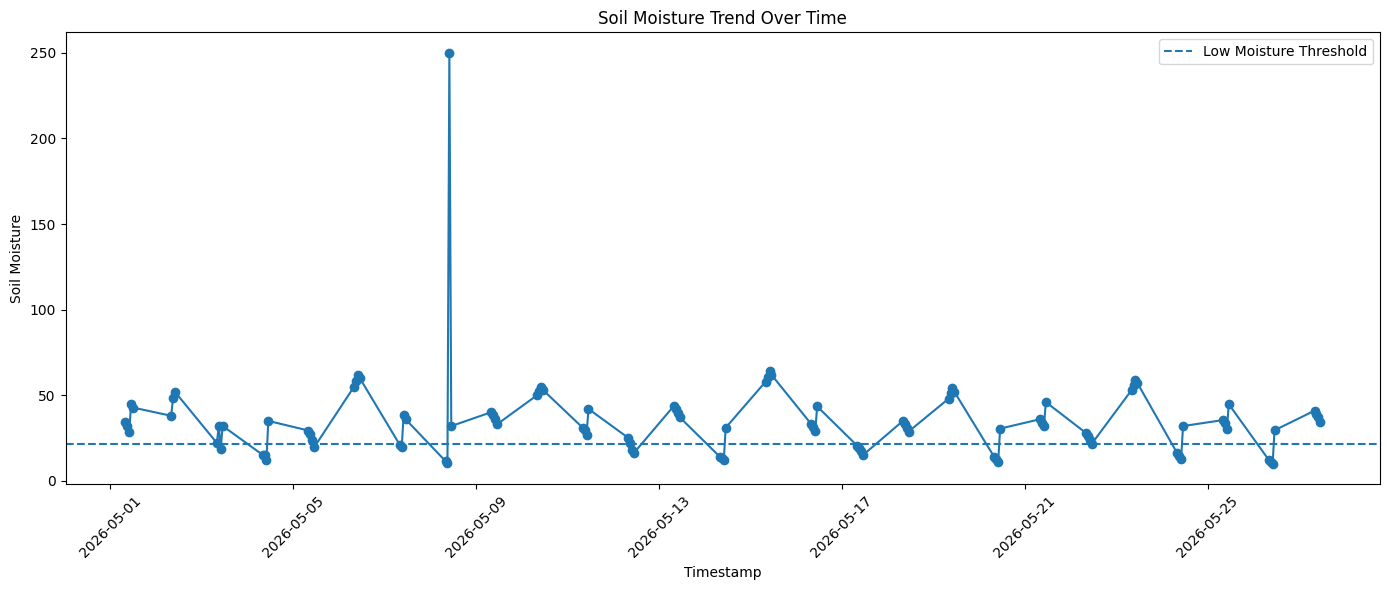

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Timestamp"],
    df["Soil_Moisture"],
    marker="o"
)

plt.axhline(
    moisture_threshold,
    linestyle="--",
    label="Low Moisture Threshold"
)

plt.xlabel("Timestamp")
plt.ylabel("Soil Moisture")
plt.title("Soil Moisture Trend Over Time")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

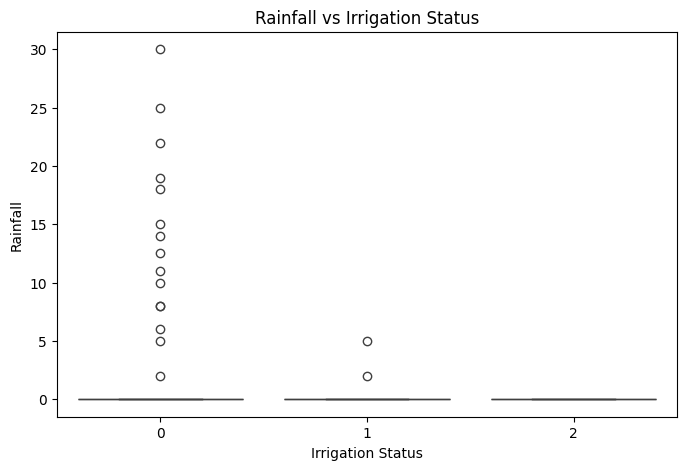

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Irrigation_Status",
    y="Rainfall"
)

plt.xlabel("Irrigation Status")
plt.ylabel("Rainfall")
plt.title("Rainfall vs Irrigation Status")

plt.show()

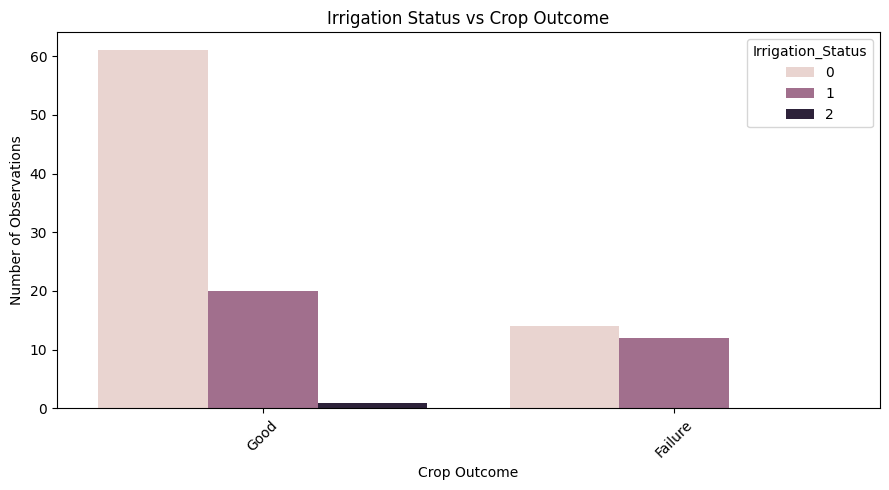

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Crop_Outcome",
    hue="Irrigation_Status"
)

plt.xlabel("Crop Outcome")
plt.ylabel("Number of Observations")
plt.title("Irrigation Status vs Crop Outcome")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

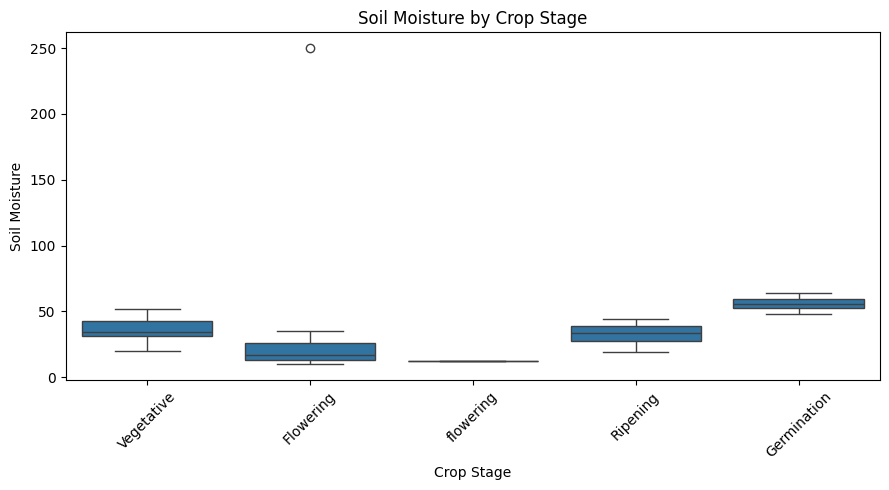

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Crop_Stage",
    y="Soil_Moisture"
)

plt.xlabel("Crop Stage")
plt.ylabel("Soil Moisture")
plt.title("Soil Moisture by Crop Stage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()